# Deutsch-Jozsa: IBM quantum hardware version

This notebook converts the simulator-based Deutsch-Jozsa course example into an IBM Quantum hardware run. It is designed to compare directly with `deutsch_jozsa_simulator_only.ipynb`.

**Main target:** 4 input qubits plus 1 output/ancilla qubit. For the balanced oracle used here, the ideal simulator output is `1111`. On hardware, `1111` should ideally remain the dominant bitstring, with other outputs caused by device noise.

In [ ]:
%pip install qiskit qiskit-aer qiskit-ibm-runtime matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.5 MB/s eta 0:00:00
  Created w

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

SHOTS = 4096


In [ ]:
def make_balanced_oracle(n: int) -> QuantumCircuit:
    """Balanced Deutsch-Jozsa oracle.

    Implements f(x) = x0 XOR x1 XOR ... XOR x(n-1) by applying a CNOT
    from every input qubit to the output/ancilla qubit.
    This is the same basic balanced-oracle form used in the course notebook.
    """
    oracle = QuantumCircuit(n + 1, name="Balanced Oracle")
    for qubit in range(n):
        oracle.cx(qubit, n)
    return oracle


def make_constant_oracle(n: int, output: int = 0) -> QuantumCircuit:
    """Constant Deutsch-Jozsa oracle.

    output=0: f(x)=0 for all x, so do nothing.
    output=1: f(x)=1 for all x, so flip the output/ancilla qubit.
    """
    oracle = QuantumCircuit(n + 1, name=f"Constant Oracle f={output}")
    if output == 1:
        oracle.x(n)
    return oracle


def deutsch_jozsa_circuit(oracle: QuantumCircuit, n: int) -> QuantumCircuit:
    """Build the Deutsch-Jozsa circuit for an n-bit input register.

    Qubits 0..n-1 are the input register.
    Qubit n is the output/ancilla qubit.
    We measure only the input register.
    """
    qc = QuantumCircuit(n + 1, n)

    # Prepare input register in superposition.
    for qubit in range(n):
        qc.h(qubit)

    # Prepare output qubit in |->.
    qc.x(n)
    qc.h(n)
    qc.barrier(label="prep")

    # Apply oracle.
    qc.compose(oracle, qubits=range(n + 1), inplace=True)
    qc.barrier(label="oracle")

    # Interference step.
    for qubit in range(n):
        qc.h(qubit)

    qc.barrier(label="measure")

    # Measure q[i] into c[i].
    # Note: Qiskit displays bitstrings in classical-register order c[n-1]...c[0].
    for i in range(n):
        qc.measure(i, i)

    return qc


def classify_deutsch_jozsa_counts(counts: dict, n: int) -> str:
    """Classify DJ result from counts.

    For Deutsch-Jozsa:
    - all-zero measured input register means constant
    - any nonzero dominant bitstring means balanced
    """
    dominant = max(counts, key=counts.get)
    zero = "0" * n
    return "constant" if dominant == zero else "balanced"


## 1. Build the same Deutsch-Jozsa circuit

This must match the simulator notebook. Do not change the oracle while comparing simulator vs hardware.

     ┌───┐      prep                      oracle ┌───┐ measure ┌─┐         
q_0: ┤ H ├───────░─────■────────────────────░────┤ H ├────░────┤M├─────────
     ├───┤       ░     │                    ░    ├───┤    ░    └╥┘┌─┐      
q_1: ┤ H ├───────░─────┼────■───────────────░────┤ H ├────░─────╫─┤M├──────
     ├───┤       ░     │    │               ░    ├───┤    ░     ║ └╥┘┌─┐   
q_2: ┤ H ├───────░─────┼────┼────■──────────░────┤ H ├────░─────╫──╫─┤M├───
     ├───┤       ░     │    │    │          ░    ├───┤    ░     ║  ║ └╥┘┌─┐
q_3: ┤ H ├───────░─────┼────┼────┼────■─────░────┤ H ├────░─────╫──╫──╫─┤M├
     ├───┤┌───┐  ░   ┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐   ░    └───┘    ░     ║  ║  ║ └╥┘
q_4: ┤ X ├┤ H ├──░───┤ X ├┤ X ├┤ X ├┤ X ├───░─────────────░─────╫──╫──╫──╫─
     └───┘└───┘  ░   └───┘└───┘└───┘└───┘   ░             ░     ║  ║  ║  ║ 
c: 4/═══════════════════════════════════════════════════════════╩══╩══╩══╩═
                                                                0  1  2  3 


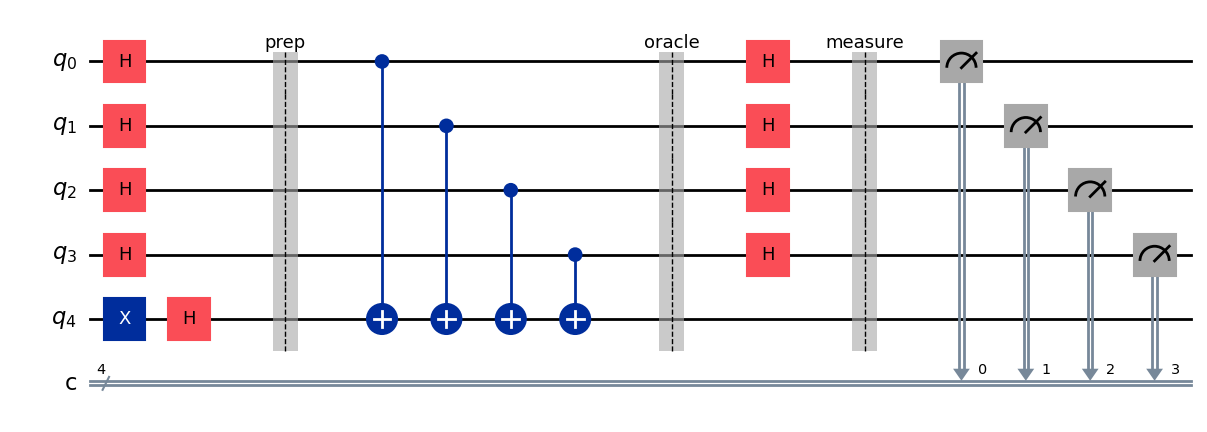

In [ ]:
n = 4
oracle = make_balanced_oracle(n)
dj_circuit = deutsch_jozsa_circuit(oracle, n)

print(dj_circuit)
dj_circuit.draw("mpl")

## 2. Connect to IBM Quantum and choose a backend

Use your saved IBM account if available. If this is your first time in the environment, uncomment the `save_account` line and paste your token.

In [ ]:
# First-time setup only. Do not share your token in screenshots or submitted files.
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token='CAyoMQZ6nheMCLQt9zMAbph1QytstHNNa0psBEkm4KBS', overwrite=True)

service = QiskitRuntimeService(channel="ibm_quantum_platform")

# Pick a real backend with enough qubits. You can also manually set one, e.g.:
# backend = service.backend("ibm_kingston")
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=n + 1)

print("Selected backend:", backend.name)
print("Backend qubits:", backend.num_qubits)
print("Backend status:", backend.status())

qiskit_runtime_service.__init__:WARNING:2026-06-30 21:59:08,040: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-30 21:59:08,460: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-30 21:59:12,033: Using instance: open-instance, plan: open


Selected backend: ibm_kingston
Backend qubits: 156
Backend status: <qiskit_ibm_runtime.models.backend_status.BackendStatus object at 0x7abaa645f800>


## 3. Transpile for the selected hardware backend

The abstract circuit is decomposed into gates supported by the chosen real device. Document depth increases because this is one source of hardware noise.

Original circuit depth: 8
Original operation counts: OrderedDict({'h': 9, 'cx': 4, 'measure': 4, 'barrier': 3, 'x': 1})
Transpiled circuit depth: 39
Transpiled operation counts: OrderedDict({'rz': 30, 'sx': 25, 'cz': 10, 'measure': 4, 'barrier': 3})


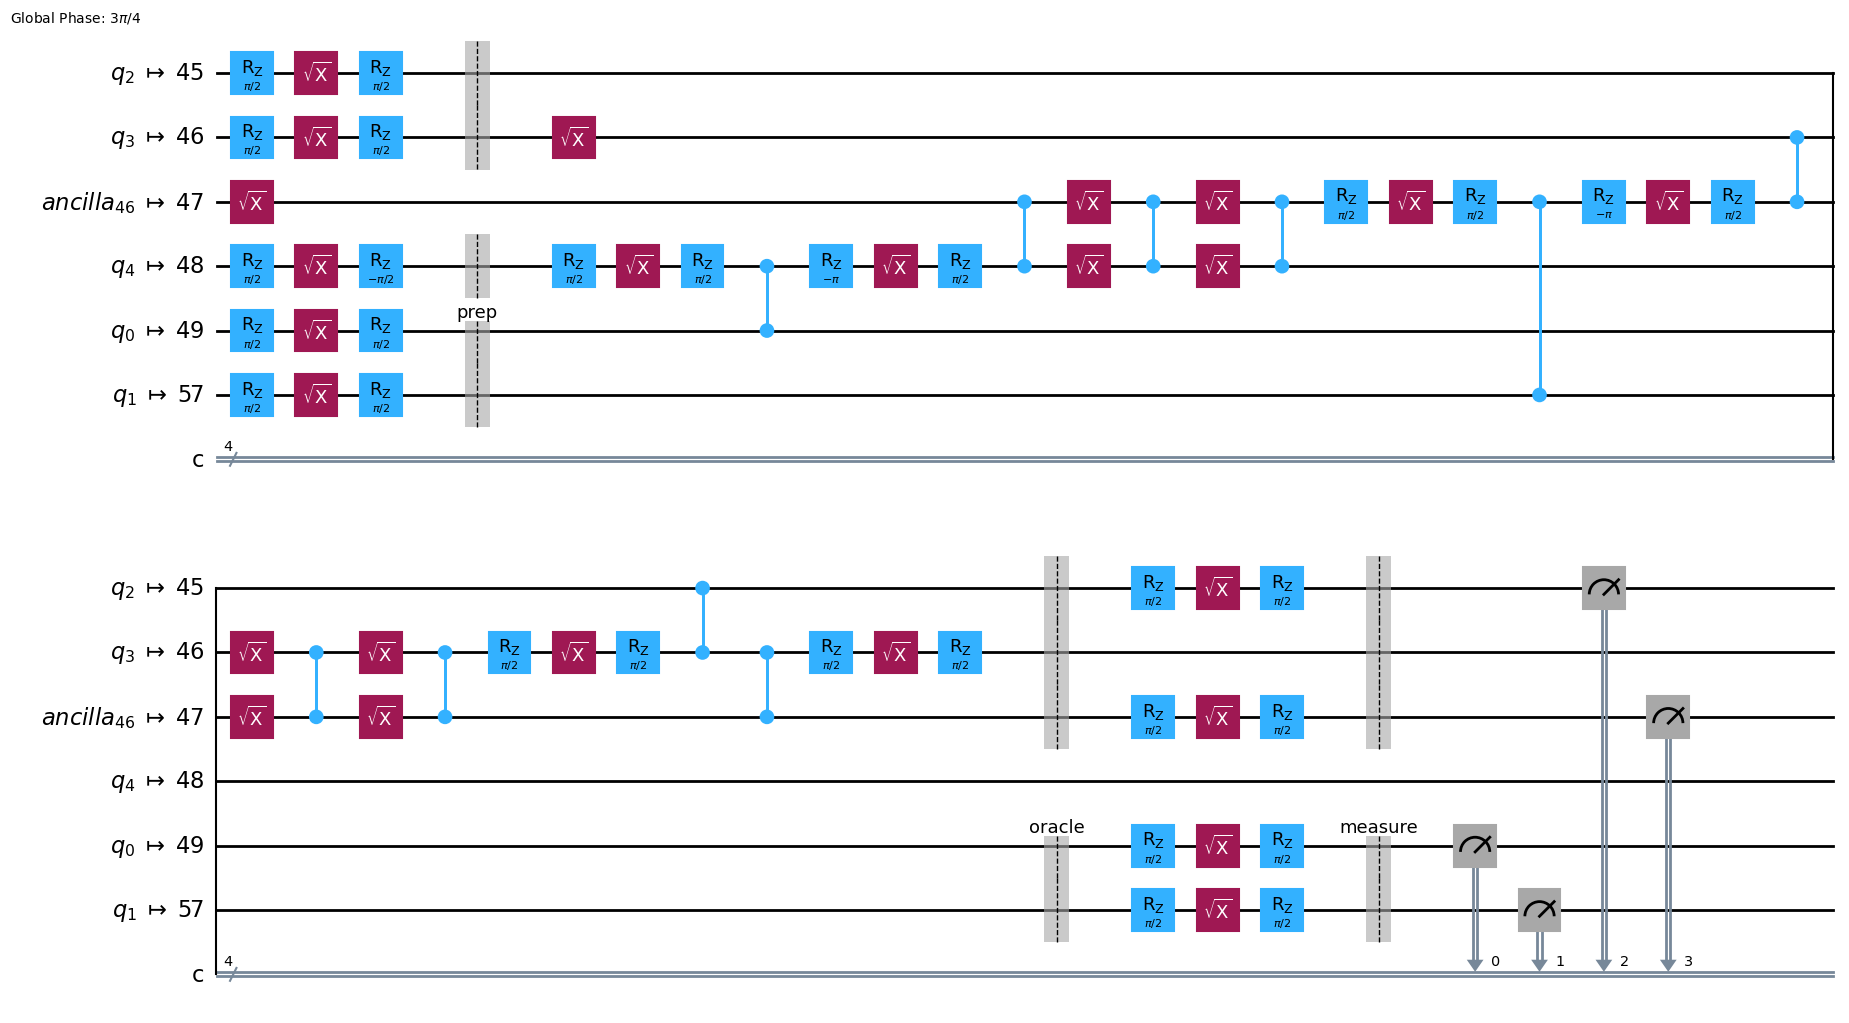

In [ ]:
print("Original circuit depth:", dj_circuit.depth())
print("Original operation counts:", dj_circuit.count_ops())

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(dj_circuit)

print("Transpiled circuit depth:", isa_circuit.depth())
print("Transpiled operation counts:", isa_circuit.count_ops())

isa_circuit.draw("mpl", idle_wires=False)

## 4. Submit the job using IBM Runtime SamplerV2

`job.result()` can appear to hang while the job waits in the real-device queue. Record this if it happens; it is part of the ChatGPT/hardware-usability findings.

In [ ]:
sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit], shots=SHOTS)

print("Job ID:", job.job_id())
print("Initial job status:", job.status())

Job ID: d923oemu9n7c73annkh0
Initial job status: QUEUED


## 5. Retrieve hardware counts

Run this after the job finishes. If it is still queued or running, wait and rerun the status cell.

Job ID: d923oemu9n7c73annkh0
Current job status: RUNNING
Hardware counts: {'1111': 3438, '0111': 146, '1110': 159, '0001': 32, '0000': 28, '0011': 57, '0010': 4, '1011': 124, '0101': 4, '1101': 58, '1001': 24, '0110': 7, '1100': 5, '1010': 6, '1000': 3, '0100': 1}
Dominant hardware bitstring: 1111
Deutsch-Jozsa hardware classification: balanced
Dominant percentage: 83.935546875


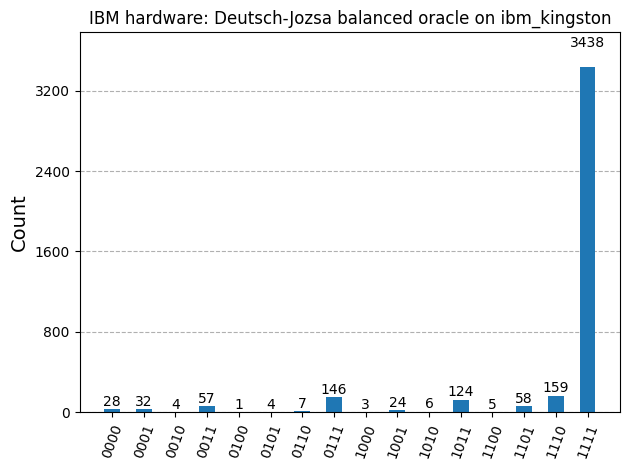

In [ ]:
print("Job ID:", job.job_id())
print("Current job status:", job.status())

result = job.result()
pub_result = result[0]

# The default classical register is usually named "c" because the circuit was created as QuantumCircuit(n+1, n).
# If the register name differs after transpilation/runtime processing, the fallback finds the register with get_counts().
try:
    counts_hw = pub_result.data.c.get_counts()
except Exception:
    counts_hw = None
    for field_name in dir(pub_result.data):
        if field_name.startswith("_"):
            continue
        field = getattr(pub_result.data, field_name)
        if hasattr(field, "get_counts"):
            counts_hw = field.get_counts()
            print(f"Counts extracted from classical register: {field_name}")
            break
    if counts_hw is None:
        print("Available data fields:", dir(pub_result.data))
        raise RuntimeError("Could not extract counts. Inspect pub_result.data to find the classical register name.")

dominant_hw = max(counts_hw, key=counts_hw.get)
classification_hw = classify_deutsch_jozsa_counts(counts_hw, n)

print("Hardware counts:", counts_hw)
print("Dominant hardware bitstring:", dominant_hw)
print("Deutsch-Jozsa hardware classification:", classification_hw)
print("Dominant percentage:", counts_hw[dominant_hw] / SHOTS * 100)

plot_histogram(counts_hw, title=f"IBM hardware: Deutsch-Jozsa balanced oracle on {backend.name}")

## 6. Research notes to fill in

Use this section for the same style of comparison as QPE and QFT.

| Field | Notes |
|---|---|
| Did ChatGPT generate code that ran immediately? |  |
| Any install/API issues? |  |
| Backend used |  |
| Original circuit depth |  |
| Transpiled circuit depth |  |
| Expected simulator result | `1111` |
| Hardware dominant result |  |
| Did hardware match expected result? |  |
| Noise impact |  |
| Any bit-ordering confusion? | Check whether `1111` is interpreted correctly. Since all bits are 1 here, bit reversal is not visible; use other oracles/scaling for stronger bit-order tests. |

### Interpretation rule

For Deutsch-Jozsa, the exact nonzero bitstring can depend on the balanced oracle. The key classification rule is:

- `0000` means constant.
- any dominant nonzero bitstring means balanced.

For this specific oracle, the ideal nonzero bitstring is `1111`.